###Meskerem Goshime, Computer Vision
###UT - Post-Graduate Program in Artificial Intelligence and Machine Learning
####February 15, 2026

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 49.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not cu

In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [ ]:
#mounting google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#loading images

images = np.load('/content/drive/MyDrive/ComputerVision/images_proj.npy')

In [ ]:
#checking the shape of the image data

images.shape

(631, 200, 200, 3)

In [ ]:
#loading the labels

labels = pd.read_csv('/content/drive/MyDrive/ComputerVision/Labels_proj.csv')
labels.shape

(631, 1)

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

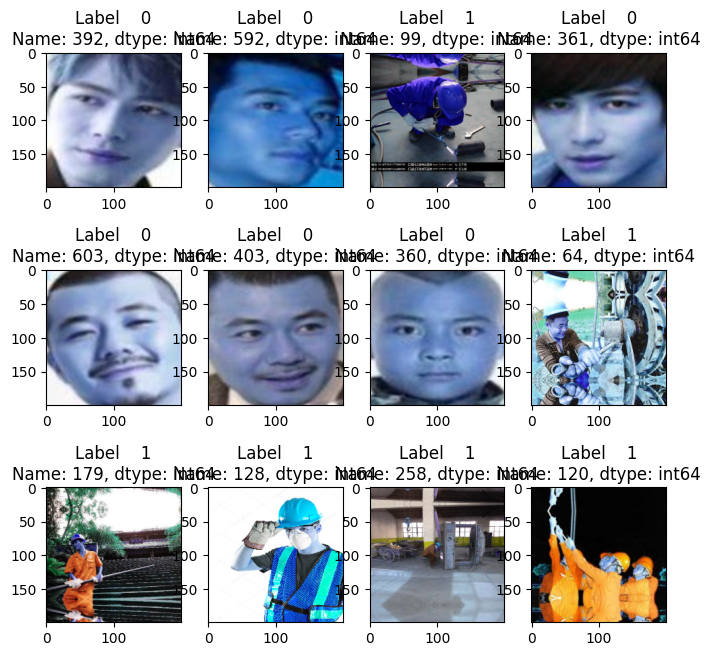

In [ ]:
num_classes=2                                                                  # Number of Classes
categories=np.unique(labels)                                                   # Obtaing the unique classes from y_train
rows = 3                                                                        # Defining number of rows=3
cols = 4                                                                        # Defining number of columns=4
fig = plt.figure(figsize=(8, 8))                                               # Defining the figure size to 10x8
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(labels))                       # Generating random indices from the data and plotting the images
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
        ax.imshow(images[random_index, :], cmap=plt.get_cmap('gray'))          # Plotting the image using cmap=gray
        ax.set_title(labels.iloc[random_index])
plt.show()

Looks like the images are in BGR format. I need to convert them to RGB.

In [ ]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

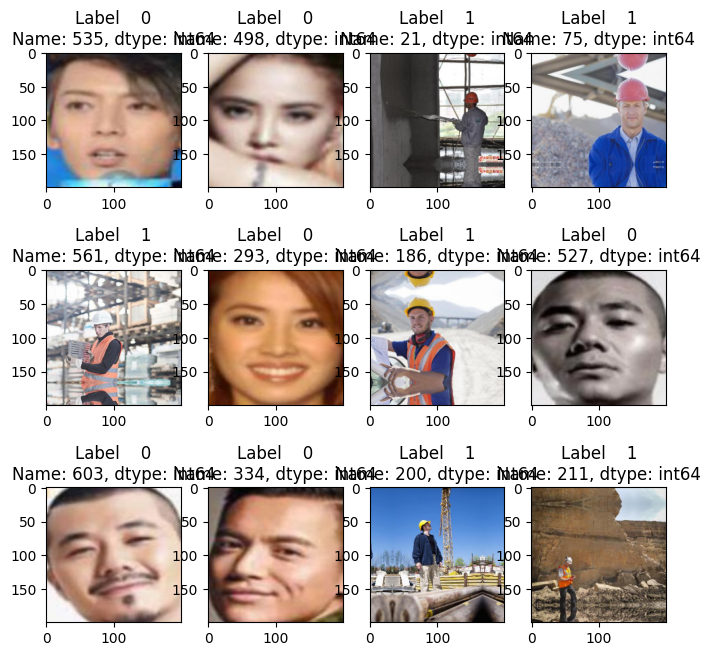

In [ ]:
num_classes=2                                                                  # Number of Classes
categories=np.unique(labels)                                                   # Obtaing the unique classes from y_train
rows = 3                                                                        # Defining number of rows=3
cols = 4                                                                        # Defining number of columns=4
fig = plt.figure(figsize=(8, 8))                                               # Defining the figure size to 10x8
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(labels))                       # Generating random indices from the data and plotting the images
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
        ax.imshow(images[random_index, :], cmap=plt.get_cmap('gray'))          # Plotting the image using cmap=gray
        ax.set_title(labels.iloc[random_index])
plt.show()

These images look more natural.

## Checking for class imbalance


       count
Label       
0        320
1        311


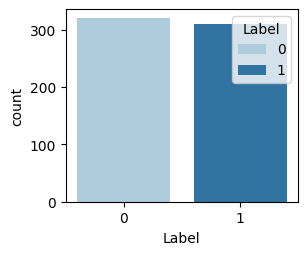

In [ ]:
# checking number if images in class 0 and class 1
counts = labels.value_counts()
counts = pd.DataFrame(counts)
counts.columns = ['count']
print(counts)

# visualizing the classes
plt.figure(figsize=(3,2.5))
sns.barplot(data=counts, x="Label", y="count", hue="Label", palette="Paired")
plt.show()

There is not a significant class imblance.

# **Data Preprocessing**

## Converting images to grayscale

In [ ]:
X_greyscale = []
for i in range(len(images)):
    img_gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    X_greyscale.append(img_gray)

In [ ]:
X_greyscale = np.array(X_greyscale)
X_greyscale.shape

(631, 200, 200)

array([[17, 25, 51, ..., 13, 18, 18],
       [20, 50, 38, ..., 15, 15, 16],
       [33, 56, 23, ..., 31, 21, 35],
       ...,
       [20, 27, 25, ..., 58,  7,  3],
       [12, 24, 32, ..., 63,  6,  1],
       [ 4,  3,  3, ..., 53,  5,  3]], dtype=uint8)
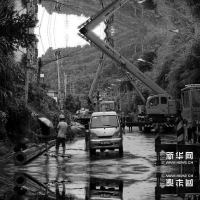

In [ ]:
X_greyscale[0]

In [ ]:
print(X_greyscale[0])

[[17 25 51 ... 13 18 18]
 [20 50 38 ... 15 15 16]
 [33 56 23 ... 31 21 35]
 ...
 [20 27 25 ... 58  7  3]
 [12 24 32 ... 63  6  1]
 [ 4  3  3 ... 53  5  3]]


### Splitting the dataset



Grey scale dataset

In [ ]:
# splitting the grey scale image dataset into training and test sets
X_train_grey, X_test_grey, y_train_grey, y_test_grey = train_test_split(X_greyscale, labels, test_size=0.2, random_state=42)
X_train_grey.shape, X_test_grey.shape, y_train_grey.shape, y_test_grey.shape

((504, 200, 200), (127, 200, 200), (504, 1), (127, 1))

Color dataset

In [ ]:
# splitting the color image dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((504, 200, 200, 3), (127, 200, 200, 3), (504, 1), (127, 1))

Resized images to 224 x 224

In [ ]:
# creating a 224 x 224 dataset for use with vgg 16 model later
X_train_224 = tf.image.resize(X_train, (224,224))
X_test_224 = tf.image.resize(X_test, (224,224))
X_train_224.shape, X_test_224.shape

(TensorShape([504, 224, 224, 3]), TensorShape([127, 224, 224, 3]))

In [ ]:
#converting from tensor to numpy array

X_train_224 = X_train_224.numpy()
X_test_224 = X_test_224.numpy()
type(X_train_224), type(X_test_224)

(numpy.ndarray, numpy.ndarray)

In [ ]:
# converting y_train value for the 224 x 224 image dataset
y_train_224 = np.array(y_train)
y_test_224 = np.array(y_test)
type(y_train_224), type(y_test_224)

(numpy.ndarray, numpy.ndarray)

### Data Normalization

In [ ]:
# normalize the greyscale dataset

X_train_grey_norm = X_train_grey.astype('float32')/255.0
X_test_grey_norm = X_test_grey.astype('float32')/255.0

In [ ]:
#checking the pixel values for the first image
X_test_grey_norm[0]

array([[0.10980392, 0.11372549, 0.11372549, ..., 0.10588235, 0.10588235,
        0.10196079],
       [0.10980392, 0.11372549, 0.11372549, ..., 0.10196079, 0.10196079,
        0.10196079],
       [0.10980392, 0.11372549, 0.11372549, ..., 0.09803922, 0.10196079,
        0.10196079],
       ...,
       [0.02352941, 0.02352941, 0.02352941, ..., 0.3254902 , 0.34509805,
        0.37254903],
       [0.02352941, 0.02352941, 0.02745098, ..., 0.32156864, 0.3254902 ,
        0.34901962],
       [0.02352941, 0.02352941, 0.02745098, ..., 0.3254902 , 0.3137255 ,
        0.32941177]], dtype=float32)

In [ ]:
# normalize the color dataset

X_train_norm = X_train.astype('float32')/255.0
X_test_norm = X_test.astype('float32')/255.0

In [ ]:
# checking the pixel values for the first image
X_train_norm[0]

array([[[0.44705883, 0.45882353, 0.49411765],
        [0.47058824, 0.48235294, 0.5176471 ],
        [0.4392157 , 0.4509804 , 0.4862745 ],
        ...,
        [0.6039216 , 0.6039216 , 0.6117647 ],
        [0.6039216 , 0.6039216 , 0.6156863 ],
        [0.6156863 , 0.6156863 , 0.62352943]],

       [[0.47843137, 0.49019608, 0.5254902 ],
        [0.47843137, 0.4862745 , 0.52156866],
        [0.44705883, 0.45882353, 0.49411765],
        ...,
        [0.6039216 , 0.6039216 , 0.6117647 ],
        [0.6039216 , 0.6039216 , 0.6117647 ],
        [0.6117647 , 0.6117647 , 0.61960787]],

       [[0.47843137, 0.49019608, 0.5254902 ],
        [0.47843137, 0.49019608, 0.5254902 ],
        [0.4627451 , 0.47843137, 0.50980395],
        ...,
        [0.60784316, 0.60784316, 0.6117647 ],
        [0.6039216 , 0.6039216 , 0.6117647 ],
        [0.60784316, 0.60784316, 0.6156863 ]],

       ...,

       [[0.64705884, 0.5294118 , 0.27450982],
        [0.5803922 , 0.6392157 , 0.47058824],
        [0.49411765, 0

In [ ]:
# normalize the 224 x 224 dataset

X_train_224_norm = X_train_224.astype('float32')/255.0
X_test_224_norm = X_test_224.astype('float32')/255.0

In [ ]:
# checking the pixel values for the first image
X_train_224_norm[0]

array([[[0.44705883, 0.45882353, 0.49411765],
        [0.4668067 , 0.47857141, 0.5138656 ],
        [0.44761902, 0.45938373, 0.49467784],
        ...,
        [0.6039216 , 0.6039216 , 0.6128151 ],
        [0.60581225, 0.60581225, 0.6169467 ],
        [0.6156863 , 0.6156863 , 0.62352943]],

       [[0.47338936, 0.48515406, 0.52044815],
        [0.47656313, 0.48556548, 0.5208596 ],
        [0.45420167, 0.4650848 , 0.5003789 ],
        ...,
        [0.6039216 , 0.6039216 , 0.6119335 ],
        [0.6052833 , 0.6052833 , 0.61365545],
        [0.612395  , 0.612395  , 0.6202381 ]],

       [[0.47843137, 0.49019608, 0.5254902 ],
        [0.47843137, 0.48931447, 0.5246086 ],
        [0.46387053, 0.47745597, 0.510648  ],
        ...,
        [0.60602367, 0.60602367, 0.6117647 ],
        [0.6047206 , 0.6047206 , 0.6125637 ],
        [0.6088935 , 0.6088935 , 0.61673665]],

       ...,

       [[0.64705884, 0.5294118 , 0.26610658],
        [0.5849353 , 0.62245023, 0.43772513],
        [0.51371926, 0

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [ ]:
def model_performance(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    pred = model.predict(predictors, batch_size=4)
    # checking which probabilities are greater than threshold

    pred = pred.numpy().reshape(-1) > 0.5

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    return(pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],))

In [ ]:
def model_performance2(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    pred = model.predict(predictors, batch_size=4)
    # checking which probabilities are greater than threshold

    pred = pred.reshape(-1) > 0.5

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    return(pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],))

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(2.5,2))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [ ]:
def plot_confusion_matrix2(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(2.5, 2))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN) with Grey Scale Images

In [ ]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
model_cnn_1 = Sequential()                                                #Sequential model
model_cnn_1.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(200, 200, 1)))    #input layer
model_cnn_1.add(MaxPooling2D(pool_size=(2, 2)))                           #pooling layer
model_cnn_1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))    #convolution layer
model_cnn_1.add(MaxPooling2D(pool_size=(2, 2)))                           #pooling layer
model_cnn_1.add(Flatten())                                                #flatten layer
model_cnn_1.add(Dense(1, activation='sigmoid'))                           #output layer
opt = SGD(learning_rate=0.01, momentum=0.9)
model_cnn_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model_cnn_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 200, 200, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │        80,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,105 (387.13 KB)

 Trainable params: 99,105 (387.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#fitting the model with the data

history_cnn_1 = model_cnn_1.fit(
            X_train_grey_norm, y_train_grey,
            epochs=15,
            validation_split=0.1,
            shuffle=True,
            batch_size=20,
            verbose=2
)

Epoch 1/15
23/23 - 4s - 173ms/step - accuracy: 0.7219 - loss: 0.5550 - val_accuracy: 0.9020 - val_loss: 0.2754
Epoch 2/15
23/23 - 1s - 32ms/step - accuracy: 0.8985 - loss: 0.2780 - val_accuracy: 0.6471 - val_loss: 0.7850
Epoch 3/15
23/23 - 1s - 29ms/step - accuracy: 0.7991 - loss: 0.5427 - val_accuracy: 0.6471 - val_loss: 1.5730
Epoch 4/15
23/23 - 1s - 29ms/step - accuracy: 0.8653 - loss: 0.4032 - val_accuracy: 0.9020 - val_loss: 0.3588
Epoch 5/15
23/23 - 1s - 29ms/step - accuracy: 0.9095 - loss: 0.2802 - val_accuracy: 0.9216 - val_loss: 0.3744
Epoch 6/15
23/23 - 1s - 29ms/step - accuracy: 0.9227 - loss: 0.2259 - val_accuracy: 0.9216 - val_loss: 0.3306
Epoch 7/15
23/23 - 1s - 31ms/step - accuracy: 0.9272 - loss: 0.1745 - val_accuracy: 0.8431 - val_loss: 0.3057
Epoch 8/15
23/23 - 1s - 32ms/step - accuracy: 0.9448 - loss: 0.1690 - val_accuracy: 0.9412 - val_loss: 0.2773
Epoch 9/15
23/23 - 1s - 55ms/step - accuracy: 0.9227 - loss: 0.2138 - val_accuracy: 0.9020 - val_loss: 0.2880
Epoch 10/

### Vizualizing the predictions

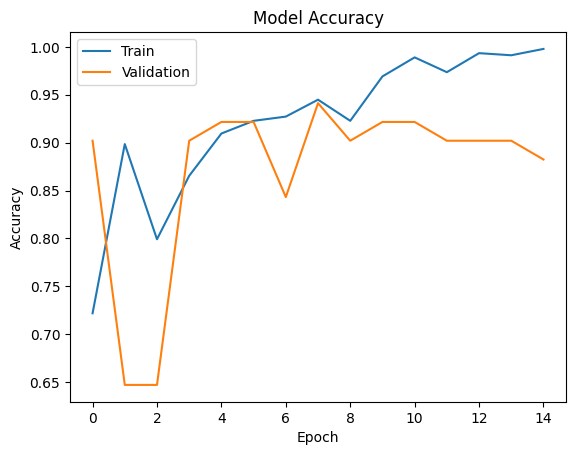

In [ ]:
plt.plot(history_cnn_1.history['accuracy'])
plt.plot(history_cnn_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#performance of model_cnn_1

print('CNN Model with Grey Scale Images - Training Performance')
cnn1_perf_train = model_performance2(model_cnn_1, X_train_grey_norm, y_train_grey)
print(cnn1_perf_train)

print('\n')

print('CNN Model with Grey Scale Images - Test Performance')
cnn1_perf_test = model_performance2(model_cnn_1, X_test_grey_norm, y_test_grey)
print(cnn1_perf_test)

CNN Model with Grey Scale Images - Training Performance
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
   Accuracy    Recall  Precision  F1 Score
0  0.936508  0.995868   0.886029  0.937743


CNN Model with Grey Scale Images - Test Performance
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
   Accuracy  Recall  Precision  F1 Score
0  0.929134     1.0   0.884615  0.938776


CNN Model with Grey Scale Images - Training Confusion Matrix
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


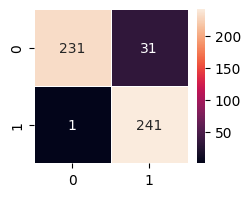

CNN Model with Grey Scale Images - Test Confusion Matrix
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


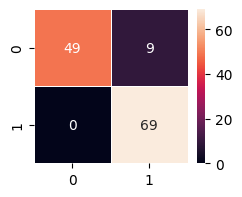

In [ ]:
#visualizing the confusion matrix

print('CNN Model with Grey Scale Images - Training Confusion Matrix')
plot_confusion_matrix(model_cnn_1, X_train_grey_norm,y_train_grey)

print('CNN Model with Grey Scale Images - Test Confusion Matrix')
plot_confusion_matrix(model_cnn_1, X_test_grey_norm,y_test_grey)

##Model 2: Simple Convolutional Neural Network (CNN) with Color Images

The performance of the CNN model with the grey scale images is low.
Testing A CNN model using the color images.

In [ ]:
model_cnn_2 = Sequential()                                                                          #Sequential model
model_cnn_2.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(200, 200, 3)))   #input layer
model_cnn_2.add(MaxPooling2D(pool_size=(2, 2)))                                                     #pooling layer
model_cnn_2.add(Conv2D(32, (3, 3), activation='relu', padding="same"))                              #convolution layer
model_cnn_2.add(MaxPooling2D(pool_size=(2, 2)))                                                     #pooling layer
model_cnn_2.add(Flatten())                                                                          #flatten layer
model_cnn_2.add(Dense(1, activation='sigmoid'))                                                     #output layer
opt = SGD(learning_rate=0.01, momentum=0.9)
model_cnn_2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model_cnn_2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 100, 100, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │        80,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,257 (391.63 KB)

 Trainable params: 100,257 (391.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#fitting the model with the data
#this model is being trained with the color image dataset

history_cnn_2 = model_cnn_2.fit(
            X_train_norm, y_train,
            epochs=15,
            validation_split=0.1,
            shuffle=True,
            batch_size=20,
            verbose=2)

Epoch 1/15
23/23 - 5s - 232ms/step - accuracy: 0.7020 - loss: 0.6570 - val_accuracy: 0.7647 - val_loss: 0.4446
Epoch 2/15
23/23 - 1s - 35ms/step - accuracy: 0.8521 - loss: 0.4220 - val_accuracy: 0.9020 - val_loss: 0.3494
Epoch 3/15
23/23 - 1s - 32ms/step - accuracy: 0.5762 - loss: 0.7085 - val_accuracy: 0.5098 - val_loss: 0.6422
Epoch 4/15
23/23 - 1s - 32ms/step - accuracy: 0.6689 - loss: 0.5844 - val_accuracy: 0.8627 - val_loss: 0.4412
Epoch 5/15
23/23 - 1s - 32ms/step - accuracy: 0.8565 - loss: 0.3883 - val_accuracy: 0.9216 - val_loss: 0.1739
Epoch 6/15
23/23 - 1s - 32ms/step - accuracy: 0.7881 - loss: 0.6938 - val_accuracy: 0.8824 - val_loss: 0.4405
Epoch 7/15
23/23 - 1s - 32ms/step - accuracy: 0.8322 - loss: 0.3768 - val_accuracy: 0.8824 - val_loss: 0.5287
Epoch 8/15
23/23 - 1s - 32ms/step - accuracy: 0.8587 - loss: 0.4933 - val_accuracy: 0.8824 - val_loss: 0.4531
Epoch 9/15
23/23 - 1s - 35ms/step - accuracy: 0.9227 - loss: 0.2936 - val_accuracy: 0.9020 - val_loss: 0.1954
Epoch 10/

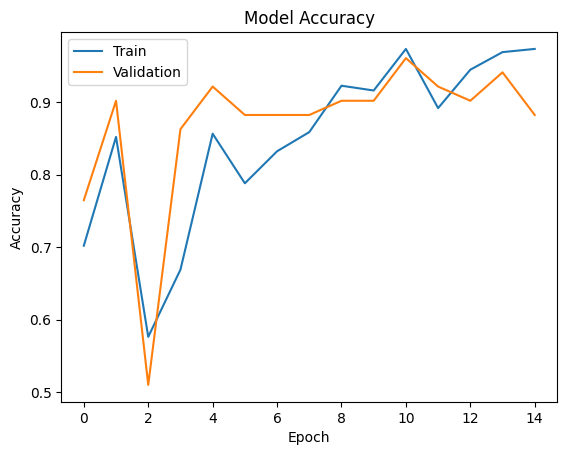

In [ ]:
plt.plot(history_cnn_2.history['accuracy'])
plt.plot(history_cnn_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Training performance
print('CNN Model with Color Images - Training Performance')
cnn2_perf_train = model_performance2(model_cnn_2, X_train_norm, y_train)
print(cnn2_perf_train)

print('\n')

# Test performance
print('CNN Model with Color Images - Test Performance')
cnn2_perf_test = model_performance2(model_cnn_2, X_test_norm, y_test)
print(cnn2_perf_test)

CNN Model with Color Images - Training Performance
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
   Accuracy    Recall  Precision  F1 Score
0   0.96627  0.954545   0.974684  0.964509


CNN Model with Color Images - Test Performance
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
   Accuracy    Recall  Precision  F1 Score
0   0.96063  0.927536        1.0  0.962406


CNN Model with Color Images - Training Confusion Matrix
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


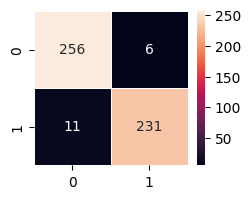

CNN Model with Color Images - Test Confusion Matrix
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step


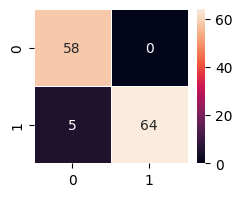

In [ ]:
#visualizing the confusion matrix

print('CNN Model with Color Images - Training Confusion Matrix')
plot_confusion_matrix(model_cnn_2, X_train_norm, y_train)

print('CNN Model with Color Images - Test Confusion Matrix')
plot_confusion_matrix(model_cnn_2, X_test_norm, y_test)

The color images improved the performance quite a bit.
Interestingly, the cnn model trained with the color images did not take longer to train than the cnn model trained with grey scale images.
The first cnn model with grey scale images took 20 seconds to train.
The second cnn model trained with color images took 19 seconds to train.

## Model 3: (VGG-16 (Base))

In [ ]:
# getting the vgg16 model

#model_vgg = VGG16(weights='imagenet')
model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
model_vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# getting the vgg layers up to the last pooling layer

transfer_layer = model_vgg.get_layer('block5_pool')
model_vgg_0 = Model(inputs=model_vgg.input, outputs=transfer_layer.output)
model_vgg_0.summary()

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Freezing the layers from the vgg model
for layer in model_vgg_0.layers:
    layer.trainable = False

In [ ]:
#checking the trainable layers
for layer in model_vgg_0.layers:
    print(layer, layer.trainable)

<InputLayer name=input_layer_8, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> False
<Conv2D name=block4_conv2, built=True> False
<Conv2D name=block4_conv3, built=True> False
<MaxPooling2D name=block4_pool, built=True> False
<Conv2D name=block5_conv1, built=True> False
<Conv2D name=block5_conv2, built=True> False
<Conv2D name=block5_conv3, built=True> False
<MaxPooling2D name=block5_pool, built=True> False


In [ ]:
model_vgg1 = Sequential()
model_vgg1.add(model_vgg_0)                     #vgg16 model upto the last pooling layer
model_vgg1.add(Flatten())                       #flatten layer
model_vgg1.add(Dense(1, activation='sigmoid'))  #output layer
model_vgg1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_37 (Functional)      │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model_vgg1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# fitting the model with the data
# the vgg model requires image size of 224x224, therefore using the 224x224 images for all the vgg models

history_vgg_1 = model_vgg1.fit(
            X_train_224_norm, y_train_224,
            epochs=8,
            validation_split=0.1,
            shuffle=True,
            batch_size=8,
            verbose=2
)

Epoch 1/8
57/57 - 10s - 176ms/step - accuracy: 0.9603 - loss: 0.1055 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 2/8
57/57 - 3s - 57ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/8
57/57 - 3s - 57ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 9.9190e-04
Epoch 4/8
57/57 - 3s - 57ms/step - accuracy: 1.0000 - loss: 9.5512e-04 - val_accuracy: 1.0000 - val_loss: 8.2796e-04
Epoch 5/8
57/57 - 4s - 64ms/step - accuracy: 1.0000 - loss: 7.5866e-04 - val_accuracy: 1.0000 - val_loss: 7.0850e-04
Epoch 6/8
57/57 - 3s - 58ms/step - accuracy: 1.0000 - loss: 6.1962e-04 - val_accuracy: 1.0000 - val_loss: 6.1541e-04
Epoch 7/8
57/57 - 3s - 58ms/step - accuracy: 1.0000 - loss: 5.1704e-04 - val_accuracy: 1.0000 - val_loss: 5.4140e-04
Epoch 8/8
57/57 - 3s - 58ms/step - accuracy: 1.0000 - loss: 4.3885e-04 - val_accuracy: 1.0000 - val_loss: 4.8144e-04


### Visualizing the prediction:

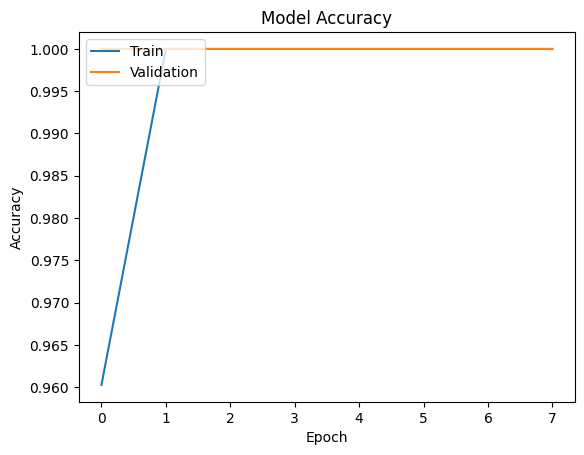

In [ ]:
plt.plot(history_vgg_1.history['accuracy'])
plt.plot(history_vgg_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#performance of model_vgg1

print('VGG Model - Base Model - Training Performance')
vgg1_perf_train = model_performance2(model_vgg1, X_train_224_norm, y_train_224)

print(vgg1_perf_train)

print('\n')

print('VGG Model - Base Model - Test Performance')
vgg1_perf_test = model_performance2(model_vgg1, X_test_224_norm, y_test_224)
print(vgg1_perf_test)

VGG Model - Base Model - Training Performance
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


VGG Model - Base Model - Test Performance
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


VGG Model - Base Model - Training Confusion Matrix
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step


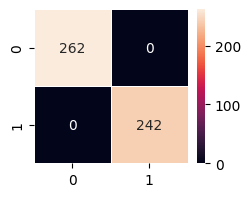

VGG Model - Base Model - Test Confusion Matrix
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step


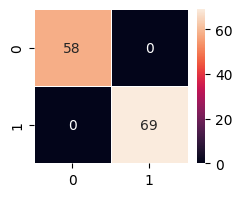

In [ ]:
#visualizing the confusion matrix for model_vgg1

print('VGG Model - Base Model - Training Confusion Matrix')
plot_confusion_matrix2(model_vgg1, X_train_224_norm,y_train_224)

print('VGG Model - Base Model - Test Confusion Matrix')
plot_confusion_matrix2(model_vgg1, X_test_224_norm,y_test_224)

The VGG base model gave perfect performance.

## Model 4: (VGG-16 (Base + FFNN))

In [ ]:
#building a model using the vgg16 layers upto the last pooling layer and additional FFFN layers

model_vgg2 = Sequential()
model_vgg2.add(model_vgg_0)                       #vgg16 model upto the last pooling layer
model_vgg2.add(MaxPooling2D(pool_size=(2, 2)))    #pooling layer
model_vgg2.add(Flatten())                         #flatten layer
model_vgg2.add(Dense(32, activation='relu'))      #dense layer
model_vgg2.add(Dense(32, activation='relu'))      #dense layer
model_vgg2.add(Dense(1, activation='sigmoid'))    #output layer
model_vgg2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_37 (Functional)      │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,863,265 (56.70 MB)

 Trainable params: 148,577 (580.38 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model_vgg2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#fitting the model with the data

history_vgg_2 = model_vgg2.fit(
            X_train_224_norm, y_train_224,
            epochs=8,
            validation_split=0.1,
            shuffle=True,
            batch_size=8, # reduced batch size to 8 to avoid 'ResourceExhaustedError'
            verbose=2
)

Epoch 1/8
57/57 - 10s - 176ms/step - accuracy: 0.9669 - loss: 0.1150 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 2/8
57/57 - 3s - 59ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/8
57/57 - 3s - 58ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 8.8157e-04
Epoch 4/8
57/57 - 3s - 58ms/step - accuracy: 1.0000 - loss: 7.4312e-04 - val_accuracy: 1.0000 - val_loss: 6.5846e-04
Epoch 5/8
57/57 - 3s - 59ms/step - accuracy: 1.0000 - loss: 4.9872e-04 - val_accuracy: 1.0000 - val_loss: 5.2214e-04
Epoch 6/8
57/57 - 3s - 61ms/step - accuracy: 1.0000 - loss: 3.6663e-04 - val_accuracy: 1.0000 - val_loss: 4.2722e-04
Epoch 7/8
57/57 - 3s - 59ms/step - accuracy: 1.0000 - loss: 2.8303e-04 - val_accuracy: 1.0000 - val_loss: 3.5763e-04
Epoch 8/8
57/57 - 3s - 60ms/step - accuracy: 1.0000 - loss: 2.2578e-04 - val_accuracy: 1.0000 - val_loss: 3.0604e-04


#### Visualizing the predictions

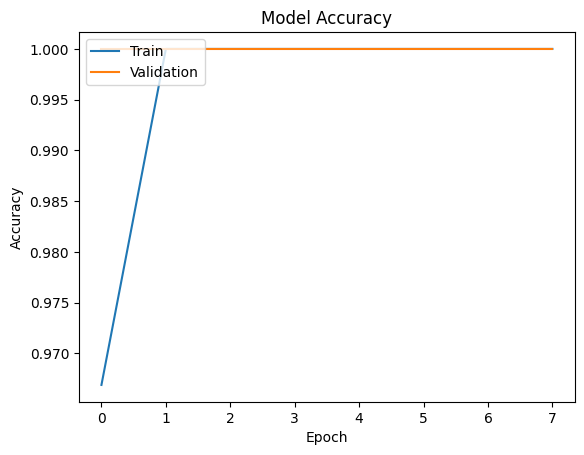

In [ ]:
plt.plot(history_vgg_2.history['accuracy'])
plt.plot(history_vgg_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
##performance of model_vgg2

print('VGG Model with FFNN - Training Performance')
vgg2_perf_train = model_performance2(model_vgg2, X_train_224_norm, y_train_224)
print(vgg2_perf_train)
vgg1_perf_train
print('\n')

print('VGG Model with FFNN - Test Performance')
vgg2_perf_test = model_performance2(model_vgg2, X_test_224_norm, y_test)
print(vgg2_perf_test)

VGG Model with FFNN - Training Performance
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


VGG Model with FFNN - Test Performance
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


VGG Model with FFNN - Training Confusion Matrix
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step


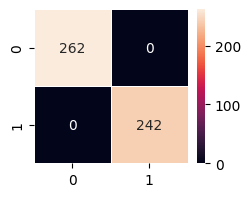



VGG Model with FFNN - Test Confusion Matrix
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step


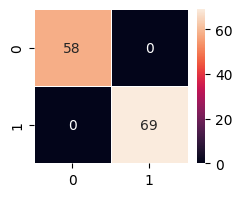

In [ ]:
#visualizing the confusion metrix for model_vgg2

print('VGG Model with FFNN - Training Confusion Matrix')
plot_confusion_matrix2(model_vgg2, X_train_224_norm,y_train_224)

print('\n')

print('VGG Model with FFNN - Test Confusion Matrix')
plot_confusion_matrix2(model_vgg2, X_test_224_norm,y_test_224)

## Model 5: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
#building a model using the vgg16 layers upto the last pooling layer and additinoal FFFN layers

model_vgg3 = Sequential()
model_vgg3.add(model_vgg_0)
model_vgg3.add(MaxPooling2D(pool_size=(2, 2)))
model_vgg3.add(Flatten())
model_vgg3.add(Dense(32, activation='relu'))
model_vgg3.add(Dense(32, activation='relu'))
model_vgg3.add(Dense(1, activation='sigmoid'))
model_vgg3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_37 (Functional)      │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,863,265 (56.70 MB)

 Trainable params: 148,577 (580.38 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model_vgg3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#generating augumented images and fitting the model

train_datagen = ImageDataGenerator(#rescale=1. / 255.0,
                              horizontal_flip = True,
                              vertical_flip = False,
                              height_shift_range= 0.1,
                              width_shift_range=0.1,
                              rotation_range=20,
                              shear_range = 0.1,
                              zoom_range=0.1)

history_vgg_3 = model_vgg3.fit(train_datagen.flow(X_train_224_norm,y_train_224,
                                       batch_size=8, # reduced batch size to 8 to avoid 'ResourceExhaustedError'
                                       seed=42,
                                       shuffle=False),
                    epochs=10,
                    steps_per_epoch=X_train_224_norm.shape[0] // 20,
                    validation_data=(X_test_224_norm,y_test),
                    verbose=1)




Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 234ms/step - accuracy: 0.8712 - loss: 0.3594 - val_accuracy: 1.0000 - val_loss: 0.0187
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 1.0000 - loss: 0.0302 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 7.9585e-04
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 1.0000 - loss: 5.0777e-04 - val_accuracy: 1.0000 - val_loss: 4.9055e-04
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9955 - loss: 0.0114 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 1.0000 - loss: 7.0913e-04 - va

#### Visualizing the predictions

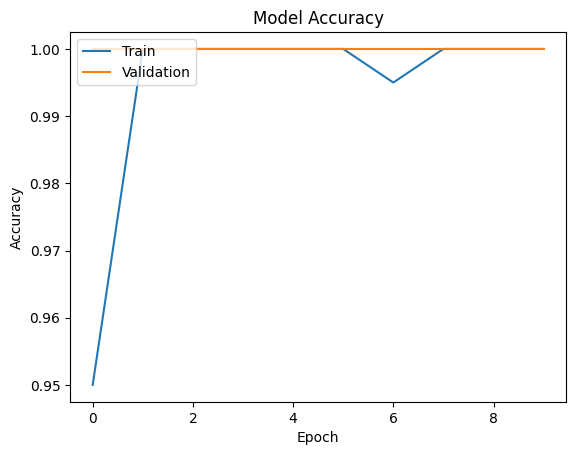

In [ ]:
plt.plot(history_vgg_3.history['accuracy'])
plt.plot(history_vgg_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Performance of model_vgg3

print('VGG Model with FFNN and Data Augumentation - Training Performance')
vgg3_perf_train = model_performance2(model_vgg3, X_train_224_norm, y_train_224)
print(vgg3_perf_train)


print('\n')

print('VGG Model with FFNN and Data Augumentation - Test Performance')
vgg3_perf_test = model_performance2(model_vgg3, X_test_224_norm, y_test)
print(vgg3_perf_test)

VGG Model with FFNN and Data Augumentation - Training Performance
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


VGG Model with FFNN and Data Augumentation - Test Performance
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


VGG Model with FFNN and Data Augumentation - Training Confusion Matrix
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step


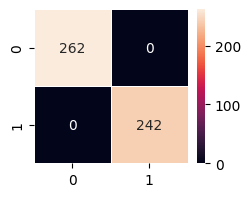



VGG Model with FFNN and Data Augumentation - Test Performancex Confusion Matrix
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 383ms/step


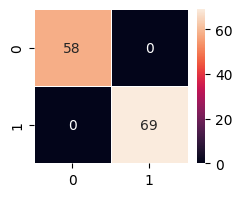

In [ ]:
#visualizing the confusion matrix of model_vgg3

print('VGG Model with FFNN and Data Augumentation - Training Confusion Matrix')
plot_confusion_matrix2(model_vgg3, X_train_224_norm,y_train_224)

print('\n')

print('VGG Model with FFNN and Data Augumentation - Test Performancex Confusion Matrix')
plot_confusion_matrix2(model_vgg3, X_test_224_norm,y_test_224)

# **Model Performance Comparison and Final Model Selection**

## Training Performance Comparison

In [ ]:
#comparing training performances of all of the models
training_performance = pd.concat([cnn1_perf_train, cnn2_perf_train, vgg1_perf_train, vgg2_perf_train, vgg3_perf_train],keys=['cnn_greyscale', 'cnn_color', 'vgg_base', 'vgg+FFNN', 'vgg3+FFNN+Augument'])
print('Training Performance Comparison', '\n', '\n', training_performance)

Training Performance Comparison 
 
                       Accuracy    Recall  Precision  F1 Score
cnn_greyscale      0  0.936508  0.995868   0.886029  0.937743
cnn_color          0  0.966270  0.954545   0.974684  0.964509
vgg_base           0  1.000000  1.000000   1.000000  1.000000
vgg+FFNN           0  1.000000  1.000000   1.000000  1.000000
vgg3+FFNN+Augument 0  1.000000  1.000000   1.000000  1.000000


## Test Performance

In [ ]:
#comparing test performances of all of the models
test_performance = pd.concat([cnn1_perf_test, cnn2_perf_test, vgg1_perf_test, vgg2_perf_test, vgg3_perf_test],keys=['cnn_greyscale', 'cnn_color', 'vgg_base', 'vgg+FFNN', 'vgg3+FFNN+Augument'])
print('Test Performance Comparison', '\n', '\n', test_performance)

Test Performance Comparison 
 
                       Accuracy    Recall  Precision  F1 Score
cnn_greyscale      0  0.929134  1.000000   0.884615  0.938776
cnn_color          0  0.960630  0.927536   1.000000  0.962406
vgg_base           0  1.000000  1.000000   1.000000  1.000000
vgg+FFNN           0  1.000000  1.000000   1.000000  1.000000
vgg3+FFNN+Augument 0  1.000000  1.000000   1.000000  1.000000


# **Actionable Insights & Recommendations**

##Project Summary:

In this project, a total of 5 models were built.

1.  CNN model with grey scale images
2.  CNN model with color images
3.  VGG16 model - base model
4.  VGG16 model with added Feed Forward Neural Network layers
5.  VGG16 model with added Feed Forward Neural Network layers and Image Augumentaiton

- The models were trained using 631 images, 311 images showing people with helmet and 320 without helmet.

- The CNN model training with the greyscale images had the lowest accuracy, precision and f1 scores, while it had a perfect recall score.

- The CNN model trained with color images seems to perform better than the CNN model trained with the greyscale images.

- All of the VGG16 based models had perfect training and test performance scores classifying all of the images correctly in both training and test data.

- This shows using the pre-trained VGG16 model clearly boosted the performance of the models.

##Recommendations:

1. I recommend using the VGG 16 model with added Feed Forward Neural Network layers and image augementation to ensure the model is used with our specific dataset and is able to classify varied images.

2. I have noticed that the images without helmets are mostly zoomed in images of the face while the images with helmet are mostly zoomed out images of workers in the workplace setting.

3. I recommend collecting better image data and retraining these models again. The image data needs to have images of people with and without helmets, but in varied workplace setting for more reliable result.





<font size=5 color='blue'>Power Ahead!</font>
___